# Logdet Method Profiling Across Matrix Sizes

This notebook profiles the runtime of different log-determinant strategies used in bayespecon.

The profiling matrices come from a regular polygon grid generated by the `bayespecon.dgp` module. Each size `n` is a grid side length producing an `n × n` rook-contiguity layout with `n²` spatial units; the spatial graph is built from the polygon GeoDataFrame returned by the DGP function.

Methods compared:

**Deterministic, exact**

- `eigenvalue`: precompute eigenvalues of `W` once; evaluate `sum(log(1 - rho * lam_i))` per call.

**Stochastic Chebyshev expansion** (Han, Malioutov & Shin 2015)

- `cheb_stochastic`: operator-valued Chebyshev polynomials with geometric (Bernstein ellipse) convergence. Same matvec cost as Barry-Pace but better accuracy at high |ρ|. **Auto-selected for n > 500.**

**Stochastic Lanczos Quadrature**

- `slq`: D-symmetrised batched Lanczos with Gauss quadrature trace estimation → Chebyshev coefficients. 300 matvecs, ρ-independent precompute.

**Polynomial / spectral approximation**

- `chebyshev`: Barry-Pace Chebyshev polynomial approximation via Clenshaw recurrence (Pace & LeSage 2004). For large `n` where eigendecomposition is impractical, the Chebyshev coefficients are built from Hutchinson stochastic trace estimates.

For each matrix size, we report:

- **setup time**: build + compile callable logdet function
- **evaluation time**: average cost to evaluate at many rho values

In [1]:
import time
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytensor
import pytensor.tensor as pt
import scipy.sparse as sp
from libpysal import graph

from bayespecon import dgp
from bayespecon._logdet import make_logdet_fn, make_logdet_numpy_fn

In [2]:
def make_grid_w(n_side: int) -> np.ndarray:
    """Create a row-standardized rook-contiguity matrix from an n_side x n_side polygon grid.

    Uses ``dgp.simulate_sar`` with ``create_gdf=True`` to generate the polygon
    geometry, then builds a contiguity graph from the returned GeoDataFrame.
    """
    gdf = dgp.simulate_sar(n=n_side, create_gdf=True)
    W = (
        graph.Graph.build_contiguity(gdf, rook=True)
        .transform("r")
        .sparse.toarray()
        .astype(np.float64)
    )
    return W


def compile_logdet_callable(
    W: np.ndarray,
    method: str,
    rho_min: float,
    rho_max: float,
):
    """Return a compiled callable f(rho) and its setup time in seconds."""
    t0 = time.perf_counter()
    rho = pt.scalar("rho")
    expr = make_logdet_fn(
        W,
        method=method,
        rho_min=rho_min,
        rho_max=rho_max,
    )(rho)
    fn = pytensor.function([rho], expr)
    setup_s = time.perf_counter() - t0
    return fn, setup_s


def bench_eval_seconds(fn, rhos: np.ndarray, repeats: int = 5) -> float:
    """Median per-call evaluation latency in microseconds."""
    run_times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        for r in rhos:
            _ = fn(float(r))
        elapsed = time.perf_counter() - t0
        run_times.append(elapsed / len(rhos))
    return float(np.median(run_times))

In [3]:
@dataclass
class ProfileConfig:
    # Grid side lengths; obs count = n_side². e.g. 10→100, 20→400, 75→5625.
    sizes: tuple[int, ...] = (10, 20, 25, 40, 50, 75)
    method_specs: tuple[dict, ...] = (
        {
            "label": "eigenvalue",
            "method": "eigenvalue",
            "rho_min": -0.95,
            "rho_max": 0.95,
        },
        {
            "label": "cheb_stochastic",
            "method": "cheb_stochastic",
            "rho_min": -0.95,
            "rho_max": 0.95,
        },
        {
            "label": "slq",
            "method": "slq",
            "rho_min": -0.95,
            "rho_max": 0.95,
        },
        {
            "label": "chebyshev",
            "method": "chebyshev",
            "rho_min": -0.95,
            "rho_max": 0.95,
        },
    )
    method_max_n: dict = None
    eval_points: int = 80
    eval_repeats: int = 3
    seed: int = 2026

    def __post_init__(self):
        if self.method_max_n is None:
            self.method_max_n = {spec["label"]: 75 for spec in self.method_specs}


cfg = ProfileConfig()

results = []
skipped = []

for n in cfg.sizes:
    W = make_grid_w(n_side=n)
    print(f"Profiling n_side={n} ({n * n} obs)...")
    for spec in cfg.method_specs:
        label = spec["label"]
        method = spec["method"]

        if n > cfg.method_max_n[label]:
            skipped.append(
                {
                    "n_side": n,
                    "n_obs": n * n,
                    "method": label,
                    "reason": "above method_max_n cap",
                }
            )
            continue

        rho_min = spec["rho_min"]
        rho_max = spec["rho_max"]
        rho_grid = np.linspace(rho_min, rho_max, cfg.eval_points)

        try:
            fn, setup_s = compile_logdet_callable(
                W,
                method=method,
                rho_min=rho_min,
                rho_max=rho_max,
            )
            eval_s = bench_eval_seconds(fn, rho_grid, repeats=cfg.eval_repeats)
            results.append(
                {
                    "n_side": n,
                    "n_obs": n * n,
                    "method": label,
                    "logdet_method": method,
                    "rho_min": rho_min,
                    "rho_max": rho_max,
                    "setup_ms": 1e3 * setup_s,
                    "eval_us": 1e6 * eval_s,
                }
            )
        except Exception as exc:
            skipped.append(
                {
                    "n_side": n,
                    "n_obs": n * n,
                    "method": label,
                    "reason": f"failed: {type(exc).__name__}: {exc}",
                }
            )

res = pd.DataFrame(results).sort_values(["method", "n_obs"]).reset_index(drop=True)
if not res.empty:
    res["total_ms"] = res["setup_ms"] + (res["eval_us"] * cfg.eval_points / 1e3)

res

Profiling n_side=10 (100 obs)...
Profiling n_side=20 (400 obs)...
Profiling n_side=25 (625 obs)...
Profiling n_side=40 (1600 obs)...
Profiling n_side=50 (2500 obs)...
Profiling n_side=75 (5625 obs)...


,n_side,n_obs,method,logdet_method,rho_min,rho_max,setup_ms,eval_us,total_ms
0,10,100,cheb_stochastic,cheb_stochastic,-0.95,0.95,570.409042,2.357812,570.597667
1,20,400,cheb_stochastic,cheb_stochastic,-0.95,0.95,553.248166,2.262501,553.429166
2,25,625,cheb_stochastic,cheb_stochastic,-0.95,0.95,519.517500,2.197400,519.693292
3,40,1600,cheb_stochastic,cheb_stochastic,-0.95,0.95,522.562083,2.117187,522.731458
4,50,2500,cheb_stochastic,cheb_stochastic,-0.95,0.95,561.715667,2.200001,561.891667
5,75,5625,cheb_stochastic,cheb_stochastic,-0.95,0.95,601.597167,2.101051,601.765251
6,10,100,chebyshev,chebyshev,-0.95,0.95,70.820916,2.219276,70.998458
7,20,400,chebyshev,chebyshev,-0.95,0.95,90.276000,2.197913,90.451833
8,25,625,chebyshev,chebyshev,-0.95,0.95,172.136583,2.215625,172.313833
9,40,1600,chebyshev,chebyshev,-0.95,0.95,454.918584,2.242187,455.097959


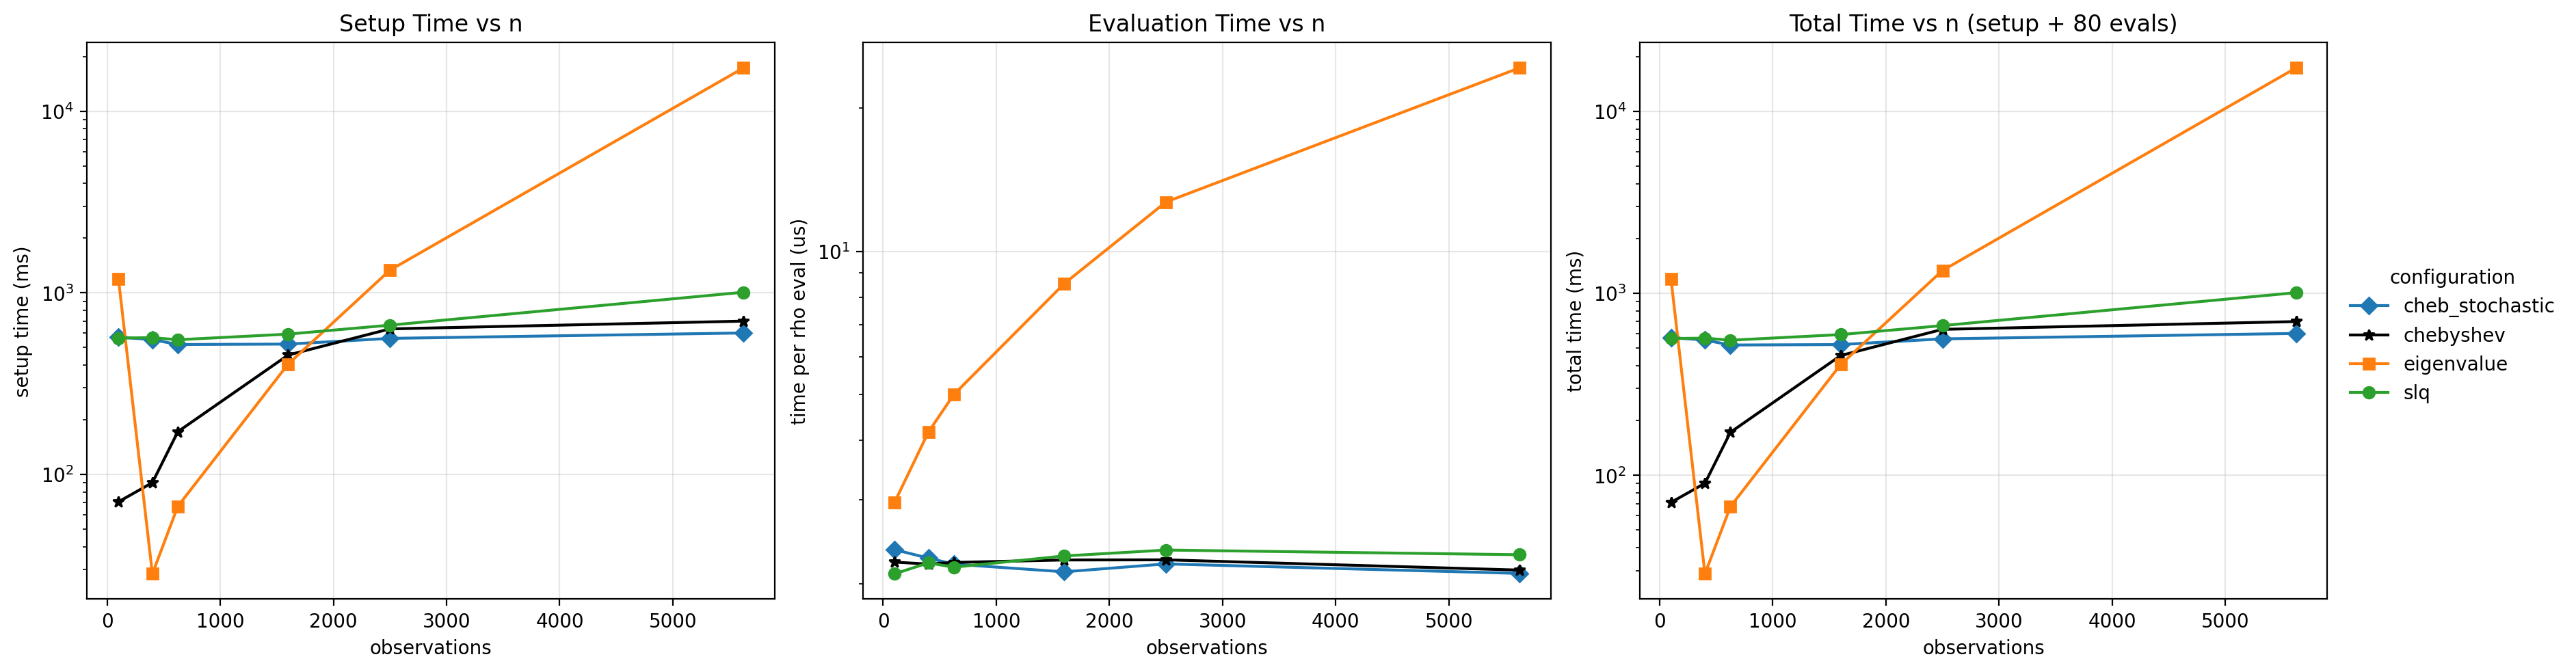

In [4]:
if res.empty:
    raise RuntimeError("No profiling results were generated.")

# Distinct color + marker per profiled configuration.
method_styles = {
    "eigenvalue": {"color": "#ff7f0e", "marker": "s", "linestyle": "-"},
    "cheb_stochastic": {"color": "#1f77b4", "marker": "D", "linestyle": "-"},
    "slq": {"color": "#2ca02c", "marker": "o", "linestyle": "-"},
    "chebyshev": {"color": "#000000", "marker": "*", "linestyle": "-"},
}

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), constrained_layout=True)

for method, grp in res.groupby("method"):
    grp = grp.sort_values("n_obs")
    style = method_styles.get(method, {"marker": "o"})
    axes[0].plot(grp["n_obs"], grp["setup_ms"], label=method, **style)
    axes[1].plot(grp["n_obs"], grp["eval_us"], label=method, **style)
    axes[2].plot(grp["n_obs"], grp["total_ms"], label=method, **style)

axes[0].set_title("Setup Time vs n")
axes[0].set_xlabel("observations")
axes[0].set_ylabel("setup time (ms)")
axes[0].set_yscale("log")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Evaluation Time vs n")
axes[1].set_xlabel("observations")
axes[1].set_ylabel("time per rho eval (us)")
axes[1].set_yscale("log")
axes[1].grid(True, alpha=0.3)

axes[2].set_title(f"Total Time vs n (setup + {cfg.eval_points} evals)")
axes[2].set_xlabel("observations")
axes[2].set_ylabel("total time (ms)")
axes[2].set_yscale("log")
axes[2].grid(True, alpha=0.3)

# Single shared legend to the right of the figure so it doesn't crowd the panels.
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    frameon=False,
    title="configuration",
)
plt.show()

In [5]:
summary = res.pivot_table(
    index="n_obs", columns="method", values=["setup_ms", "eval_us", "total_ms"]
).sort_index()
display(summary)

if skipped:
    skipped_df = (
        pd.DataFrame(skipped).sort_values(["n_side", "method"]).reset_index(drop=True)
    )
    print("Skipped combinations (due to safety caps or failures):")
    display(skipped_df)

eval_us                                       setup_ms  \
method cheb_stochastic chebyshev eigenvalue       slq cheb_stochastic   
n_obs                                                                   
100           2.357812  2.219276   2.959375  2.096349      570.409042   
400           2.262501  2.197913   4.167187  2.210938      553.248166   
625           2.197400  2.215625   4.997912  2.165101      519.517500   
1600          2.117187  2.242187   8.550000  2.286462      522.562083   
2500          2.200001  2.243750  12.699475  2.352599      561.715667   
5625          2.101051  2.134900  24.317713  2.300000      601.597167   

                                                     total_ms              \
method   chebyshev    eigenvalue          slq cheb_stochastic   chebyshev   
n_obs                                                                       
100      70.820916   1196.023291   563.875250      570.597667   70.998458   
400      90.276000     28.423667   566.928667      553.429166   90.451833   
625     172.136583     66.905625   552.104041      519.693292  172.313833   
1600    454.918584    405.574125   592.865250      522.731458  455.097959   
2500    633.433708   1333.534209   664.161917      561.891667  633.613208   
5625    698.955375  17292.095416  1007.613417      601.765251  699.126167   

                                   
method    eigenvalue          slq  
n_obs                              
100      1196.260041   564.042958  
400        28.757042   567.105542  
625        67.305458   552.277249  
1600      406.258125   593.048167  
2500     1334.550167   664.350125  
5625    17294.040833  1007.797417

## Logdet Approximation Accuracy

This section directly compares how accurately each stochastic method approximates the true log-determinant curve, independent of sampling noise. We compute the exact log|I - ρW| via eigenvalues and compare against each method's approximation across a dense ρ grid.


,method,logdet_method,max_err,mean_err,rmse
0,chebyshev,chebyshev,0.004307,0.000746,0.001017
1,slq,slq,5.246769,0.763842,1.299353


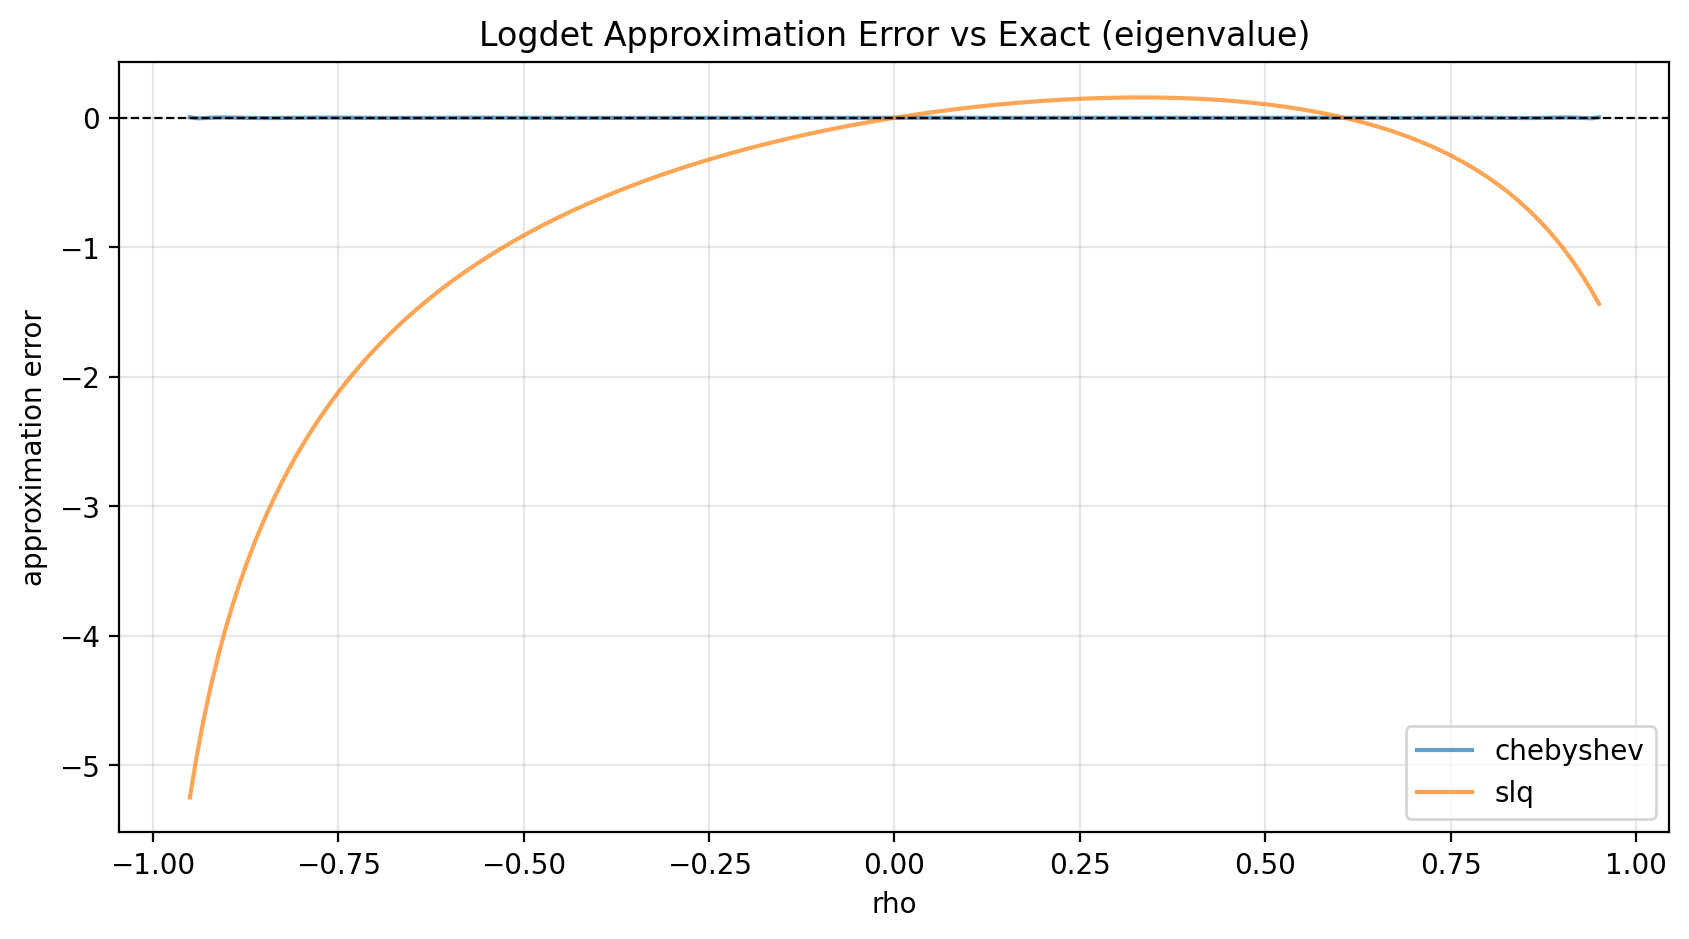

In [6]:
from bayespecon._logdet import (
    slq_logdet_eval,
    slq_logdet_precompute,
)

# Use the same W from the last profiling run (or regenerate)
W_accuracy = make_grid_w(n_side=25)
W_sp = sp.csr_matrix(W_accuracy)

# Exact logdet via eigenvalues
W_dense = W_sp.toarray()
eigs = np.linalg.eigvals(W_dense)
rho_grid_acc = np.linspace(-0.95, 0.95, 200)
exact_logdet = np.array([np.sum(np.log(np.abs(1 - r * eigs))) for r in rho_grid_acc])

# Chebyshev approximation (coefficients built from exact eigenvalues when available)
cheb_fn = make_logdet_numpy_fn(
    W_sp,
    eigs,
    method="chebyshev",
    rho_min=-0.95,
    rho_max=0.95,
)
cheb_approx = np.array([cheb_fn(r) for r in rho_grid_acc])
cheb_err = np.abs(cheb_approx - exact_logdet)

# SLQ approximation (Arnoldi-based, ρ-independent precompute)
slq_pre = slq_logdet_precompute(
    W_sp, n_probes=20, lanczos_deg=30, rng=np.random.default_rng(0)
)
slq_approx = np.array([slq_logdet_eval(slq_pre, r) for r in rho_grid_acc])
slq_err = np.abs(slq_approx - exact_logdet)

acc_df = pd.DataFrame(
    [
        {
            "method": "chebyshev",
            "logdet_method": "chebyshev",
            "max_err": cheb_err.max(),
            "mean_err": cheb_err.mean(),
            "rmse": np.sqrt((cheb_err**2).mean()),
        },
        {
            "method": "slq",
            "logdet_method": "slq",
            "max_err": slq_err.max(),
            "mean_err": slq_err.mean(),
            "rmse": np.sqrt((slq_err**2).mean()),
        },
    ]
)
display(acc_df)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(rho_grid_acc, cheb_approx - exact_logdet, label="chebyshev", alpha=0.7)
ax.plot(rho_grid_acc, slq_approx - exact_logdet, label="slq", alpha=0.7)
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("rho")
ax.set_ylabel("approximation error")
ax.set_title("Logdet Approximation Error vs Exact (eigenvalue)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## Coefficient and Fit-Time Comparison Across Logdet Methods

This section uses a regular polygon grid generated by `bayespecon.dgp` to simulate one SAR dataset, maps the simulated response, and estimates the same SAR model using each `logdet_method`.

We compare:

- posterior mean coefficients (`rho`, `beta_0`, `beta_1`, `beta_2`)
- total wall-clock time to estimate each model

To keep this section runnable in docs contexts, sampling is intentionally modest.


In [9]:
from bayespecon import SAR


def simulate_sar_data(n_side: int = 25, seed: int = 2026):
    """Simulate SAR data on an n_side x n_side polygon grid using the DGP module."""
    rng = np.random.default_rng(seed)
    beta_true = np.array([1.0, 0.8, -0.5], dtype=np.float64)
    rho_true = 0.35
    sigma_true = 0.7

    gdf = dgp.simulate_sar(
        n=n_side,
        rho=rho_true,
        beta=beta_true,
        sigma=sigma_true,
        rng=rng,
        create_gdf=True,
    )
    # Keep the SAR parameterization consistent with model assumptions.
    W_graph = graph.Graph.build_contiguity(gdf, rook=True).transform("r")
    y = gdf["y"].to_numpy()
    X_cols = [c for c in gdf.columns if c.startswith("X_")]
    X = gdf[X_cols].to_numpy()
    return gdf, y, X, W_graph, rho_true, beta_true


def fit_sar_for_method(
    y,
    X,
    W,
    method: str,
    label: str | None = None,
    draws: int = 1000,
    tune: int = 1000,
    seed: int = 2026,
):
    """Fit SAR with a specific logdet configuration and return posterior means + runtime."""
    t0 = time.perf_counter()

    model = SAR(
        y=y,
        X=X,
        W=W,
        logdet_method=method,
    )
    idata = model.fit(
        draws=draws,
        tune=tune,
        chains=2,
        cores=1,
        random_seed=seed,
        target_accept=0.95,
        progressbar=False,
        compute_convergence_checks=False,
    )

    elapsed_s = time.perf_counter() - t0
    beta_mean = idata.posterior["beta"].mean(("chain", "draw")).to_numpy()
    rho_mean = float(idata.posterior["rho"].mean(("chain", "draw")).to_numpy())

    return {
        "method": label or method,
        "logdet_method": method,
        "beta_mean": beta_mean,
        "rho_mean": rho_mean,
        "fit_seconds": elapsed_s,
    }


# Build the dataset once and sweep the methods we actually compare.
gdf_model, y_model, X_model, W_model, rho_true, beta_true = simulate_sar_data(n_side=25)

methods_for_model = [
    {"label": "eigenvalue", "method": "eigenvalue"},
    {"label": "slq", "method": "slq"},
    {"label": "chebyshev", "method": "chebyshev"},
    {"label": "cheb_stochastic", "method": "cheb_stochastic"},
]

fit_rows = []
for spec in methods_for_model:
    print(f"Fitting SAR with logdet_method={spec['method']} ...")
    fit_rows.append(
        fit_sar_for_method(
            y_model,
            X_model,
            W_model,
            method=spec["method"],
            label=spec["label"],
        )
    )

coef_df = pd.DataFrame(fit_rows)
display(coef_df)

Fitting SAR with logdet_method=eigenvalue ...


/Users/knaaptime/Dropbox/projects/bayespecon/bayespecon/_logdet/_jax.py:187: ComplexWarning: Casting complex values to real discards the imaginary part
  W_arr = np.asarray(W, dtype=np.float64)


Fitting SAR with logdet_method=slq ...
Fitting SAR with logdet_method=chebyshev ...
Fitting SAR with logdet_method=cheb_stochastic ...


,method,logdet_method,beta_mean,rho_mean,fit_seconds
0,eigenvalue,eigenvalue,"[0.882495681244159, 0.8103393651593632, -0.519...",0.381694,1.303916
1,slq,slq,"[0.8763578997901176, 0.8099742211859317, -0.51...",0.385858,1.300075
2,chebyshev,chebyshev,"[0.8832536082971867, 0.8103831188281468, -0.51...",0.381213,1.570199
3,cheb_stochastic,cheb_stochastic,"[0.8853103775885615, 0.8105045638773062, -0.51...",0.379828,1.471763


## Notes

- `eigenvalue` carries a one-time O(n³) eigendecomposition cost, then evaluates in O(n) per `rho`. Strong choice for repeated evaluation at moderate n.
- `slq` runs Arnoldi iteration on `W` once (300 matvecs by default), producing Gauss quadrature rules that can evaluate at any `rho` in O(k) time. Best accuracy in the moderate-ρ range (0.3–0.7) where the sampler spends most time.
- `chebyshev` builds Chebyshev coefficients once, then evaluates in O(m) per call. For small matrices or supplied eigenvalues it uses exact spectral coefficients; for large matrices it uses Barry-Pace Hutchinson stochastic trace estimates.
- **Parameter ranges:** All methods profiled on the symmetric range `[-0.95, 0.95]`.
- Adjust `ProfileConfig.sizes` and `method_max_n` for deeper stress tests.


/Users/knaaptime/Dropbox/projects/bayespecon/bayespecon/_logdet/_jax.py:187: ComplexWarning: Casting complex values to real discards the imaginary part
  W_arr = np.asarray(W, dtype=np.float64)


,method,logdet_method,ess_rho
0,eigenvalue,eigenvalue,1760.0
1,slq,slq,1897.0
2,chebyshev,chebyshev,1889.0
3,cheb_stochastic,cheb_stochastic,1822.0


<Axes: title={'center': 'Effective Sample Size for rho by Logdet Configuration'}, xlabel='method', ylabel='ESS (rho)'>

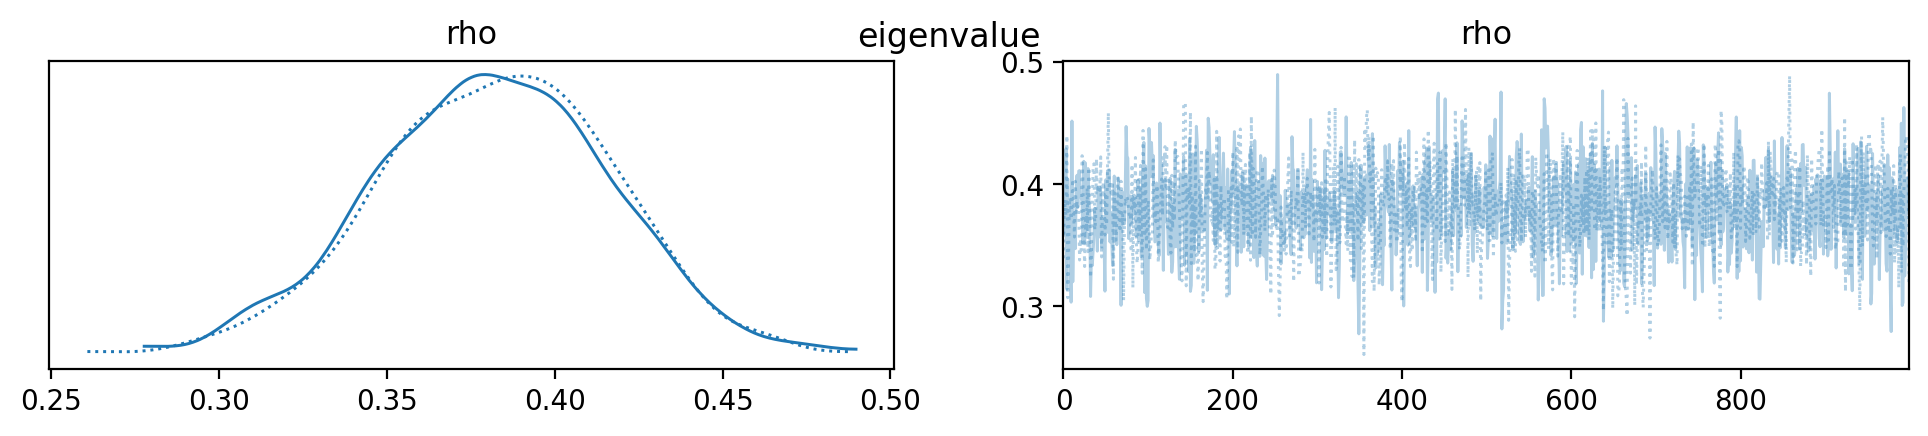

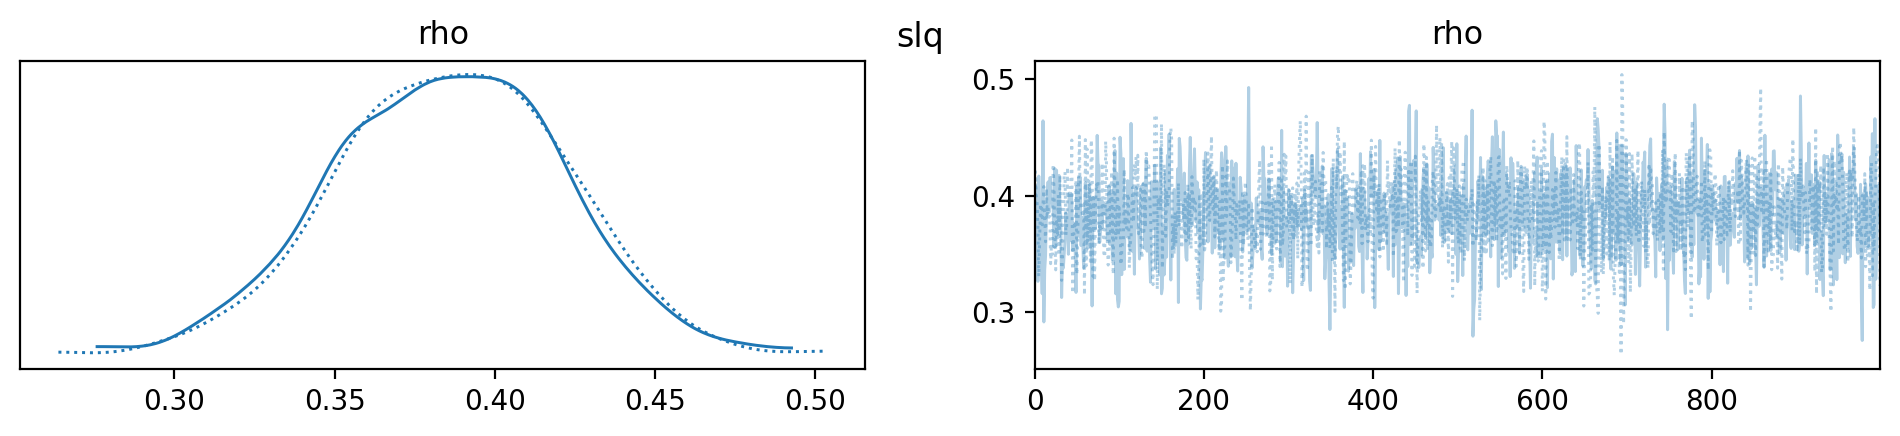

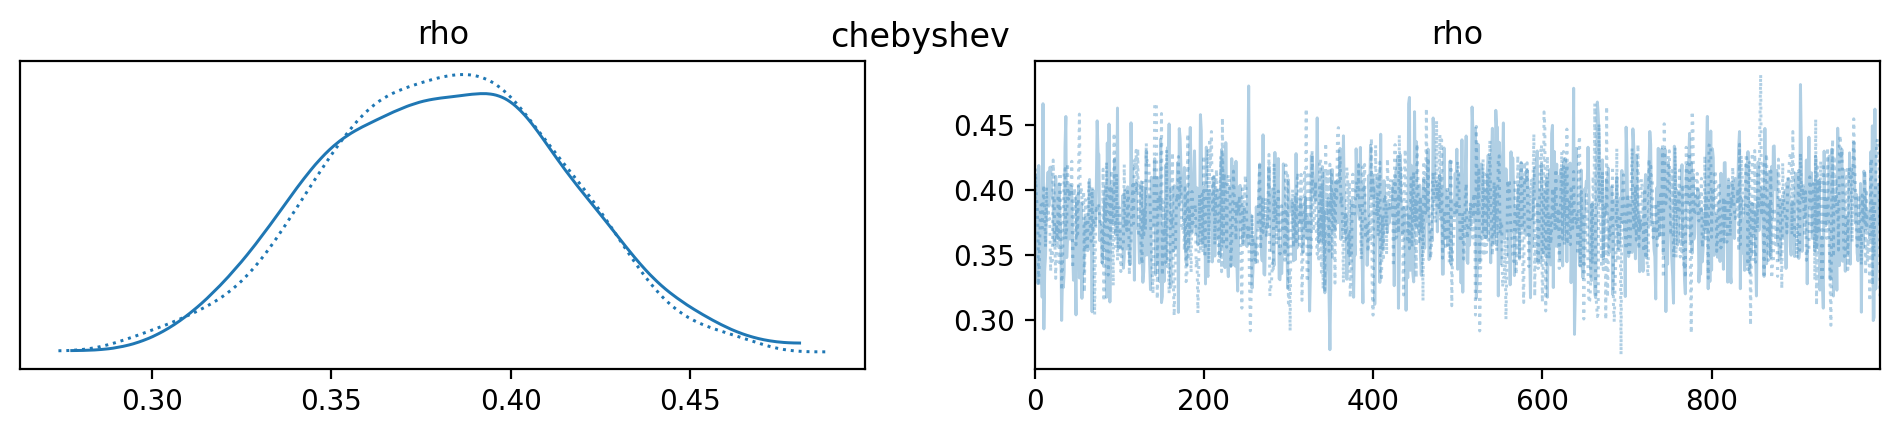

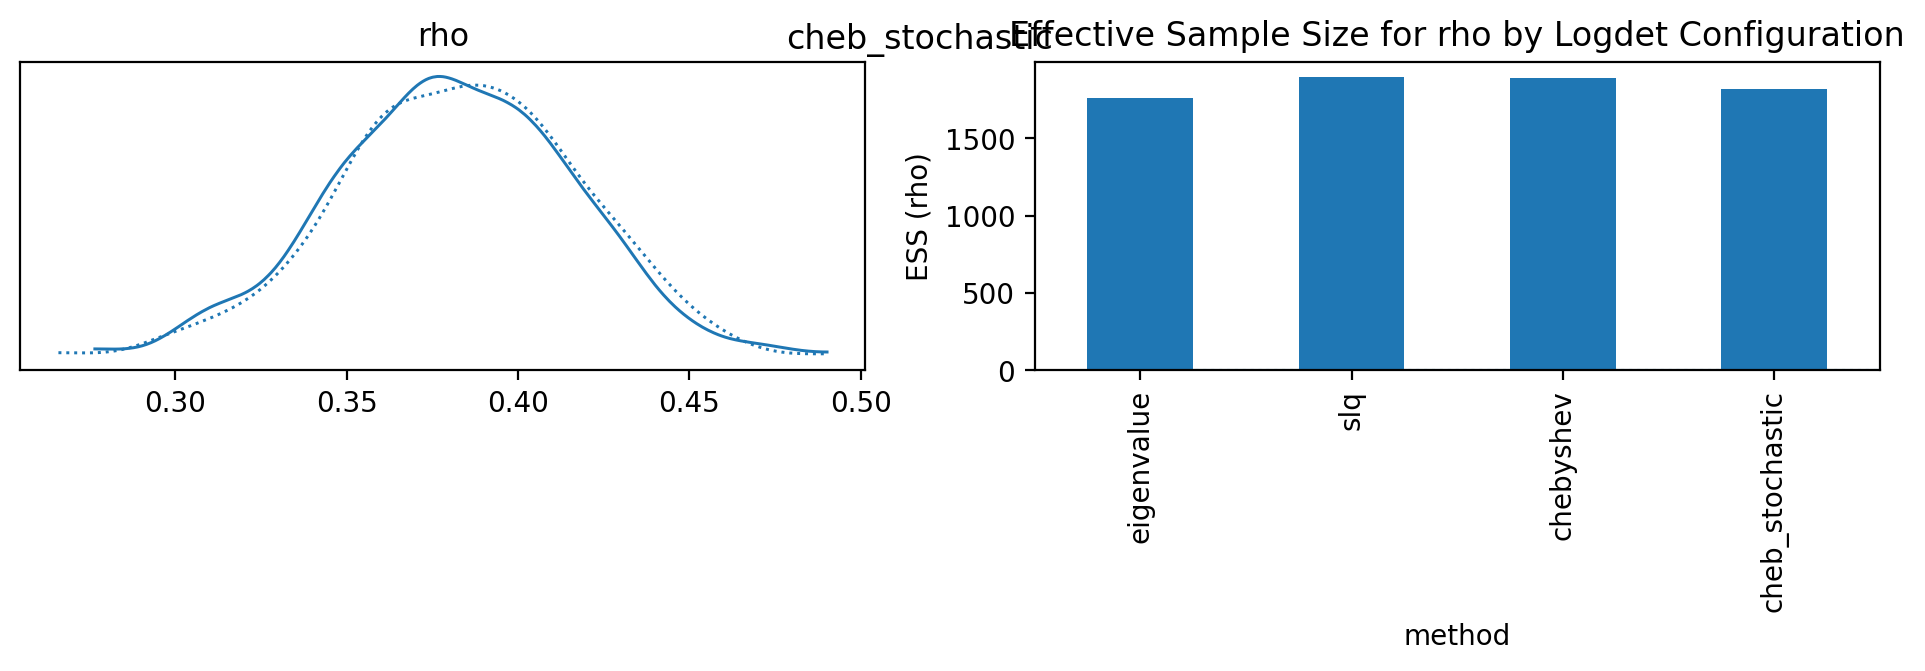

In [10]:
import arviz as az
import pandas as pd

# Refit each logdet configuration and compare effective sample sizes for rho.
ess_rows = []
for spec in methods_for_model:
    label = spec["label"]
    model = SAR(
        y=y_model,
        X=X_model,
        W=W_model,
        logdet_method=spec["method"],
        priors={"rho_lower": -1, "rho_upper": 1},
    )
    idata = model.fit(
        draws=1000,
        tune=1000,
        chains=2,
        cores=-1,
        random_seed=2026,
        target_accept=0.95,
        progressbar=False,
        compute_convergence_checks=False,
    )
    summary = az.summary(idata, var_names=["rho"])
    ess = summary.loc["rho", "ess_bulk"]
    ess_rows.append(
        {
            "method": label,
            "logdet_method": spec["method"],
            "ess_rho": ess,
        }
    )
    az.plot_trace(idata, var_names=["rho"], compact=True, legend=False)
    plt.suptitle(label)

ess_df = pd.DataFrame(ess_rows)
display(ess_df)

ess_df.set_index("method")["ess_rho"].plot.bar(
    ylabel="ESS (rho)", title="Effective Sample Size for rho by Logdet Configuration"
)

## Method selection policy

The auto-selector (`logdet_method=None`) chooses:

- `eigenvalue` for `n ≤ 500` (exact, fast per-call evaluation)
- `slq` for `n > 500` (Arnoldi-based Stochastic Lanczos Quadrature, 300 matvecs, ρ-independent)

Manual overrides:

1. **Default for most work.** Leave `logdet_method=None` and let the auto-selector choose. For large sparse problems this resolves to `slq`.
2. **Exact at moderate n.** Use `logdet_method="eigenvalue"` when an O(n³) eigendecomposition is affordable and you want bit-for-bit reproducibility.
3. **Polynomial approximation.** Use `logdet_method="chebyshev"` for near-minimax polynomial approximation via Clenshaw recurrence.
4. **Reporting and publication.** Record `logdet_method` and `rho` bounds in every benchmark or model report.
